In [1]:
# Calculate and visualize the overall churn rate.
# Explore customer distribution by variousdemographics.
# Analyze tenure distribution.
# Investigate relationships between churn anddifferent contract types/payment methods.
# Statistical analysis skills.
# Data visualization expertise.
# Ability to interpret data patterns and trends.
# Understanding of exploratory data analysistechniques.
# Tasks 2: Exploratory Data Analysis (EDA)
# Description:
# Skills :

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("CleanedData.csv",index_col='customerID')

In [4]:
df.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,1,0,0,1,1,0,...,0,0,0,1,0,0,1,0,1,0
5575-GNVDE,0,34,56.95,1889.50,0,1,1,0,1,0,...,1,0,1,0,0,0,0,1,1,0


In [5]:
df.isna().sum()

SeniorCitizen                              0
tenure                                     0
MonthlyCharges                             0
TotalCharges                               0
gender_Female                              0
gender_Male                                0
Partner_No                                 0
Partner_Yes                                0
Dependents_No                              0
Dependents_Yes                             0
PhoneService_No                            0
PhoneService_Yes                           0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSecurity_Yes                         0
OnlineBackup_No                            0
OnlineBack

In [6]:
#count total Chrun_Yes
customer_lost=df.Churn_Yes.value_counts()

customer_lost[1]

np.int64(1869)

In [7]:
customer_lost

Churn_Yes
0    5174
1    1869
Name: count, dtype: int64

In [8]:
#total no of customer at the start
total=df.Churn_Yes.shape[0]
total

7043

In [9]:
chrum_rate=(customer_lost/total)*100

In [10]:
chrum_rate[1]

np.float64(26.536987079369588)

<Axes: xlabel='Churn_Yes', ylabel='count'>

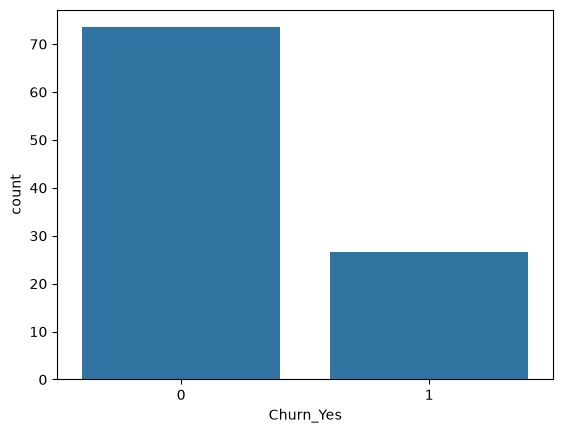

In [11]:
sns.barplot(data=chrum_rate)

In [12]:
df.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,1,0,0,1,1,0,...,0,0,0,1,0,0,1,0,1,0
5575-GNVDE,0,34,56.95,1889.50,0,1,1,0,1,0,...,1,0,1,0,0,0,0,1,1,0


In [13]:
female=df.gender_Female.value_counts()



In [14]:
#in this 0 gives male and 1 gives female 
female

gender_Female
0    3555
1    3488
Name: count, dtype: int64

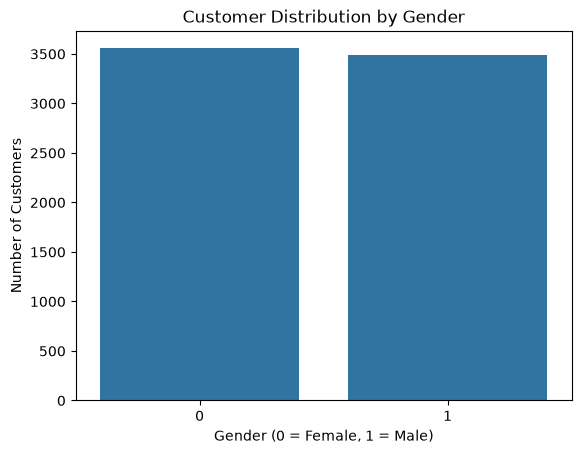

In [15]:
sns.barplot(data=female)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
df.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,1,0,0,1,1,0,...,0,0,0,1,0,0,1,0,1,0
5575-GNVDE,0,34,56.95,1889.50,0,1,1,0,1,0,...,1,0,1,0,0,0,0,1,1,0


In [20]:
senior=df.SeniorCitizen.value_counts()

<Axes: xlabel='SeniorCitizen', ylabel='count'>

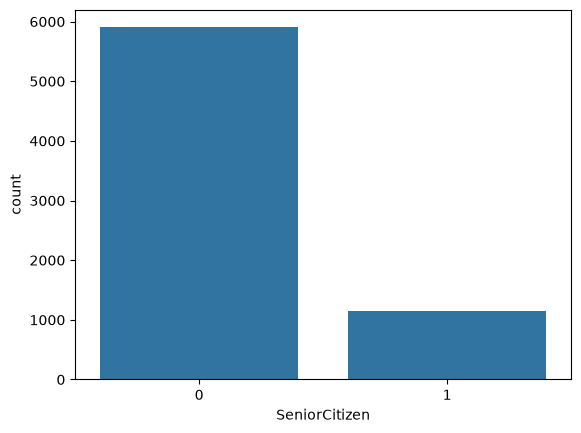

In [21]:
sns.barplot(data=senior)

In [22]:
partner=df.Partner_Yes.value_counts()

<Axes: xlabel='Partner_Yes', ylabel='count'>

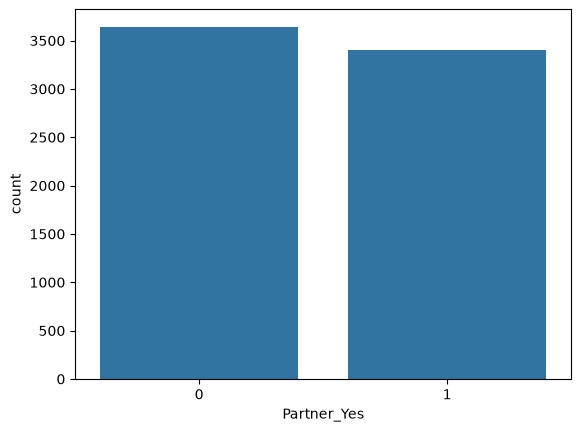

In [23]:
sns.barplot(data=partner)

In [24]:
pd.crosstab(df["gender_Male"], df["Churn_Yes"])

Churn_Yes,0,1
gender_Male,,
0,2549,939
1,2625,930


In [25]:
pd.crosstab(df['Partner_Yes'],df['Churn_Yes'])

Churn_Yes,0,1
Partner_Yes,,
0,2441,1200
1,2733,669


In [ ]:
#Analyze tenure distribution.
df.tenure.describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

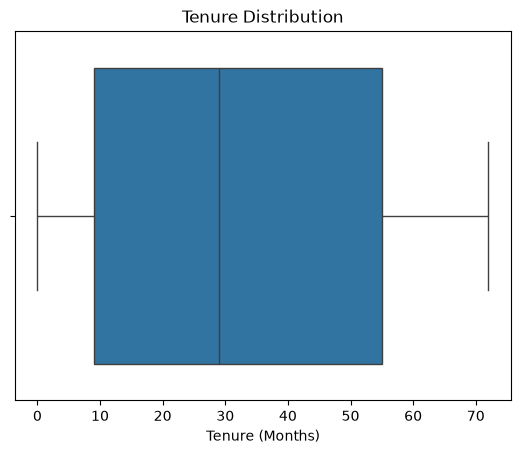

In [ ]:
sns.boxplot(x=df["tenure"])
plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

In [34]:
#Investigate relationships between churn anddifferent contract types/payment methods.

print(f"{pd.crosstab(df['Churn_Yes'],df['Contract_One year'])}")
print(f"{pd.crosstab(df['Churn_Yes'],df['Contract_Two year'])}")

Contract_One year     0     1
Churn_Yes                    
0                  3867  1307
1                  1703   166
Contract_Two year     0     1
Churn_Yes                    
0                  3527  1647
1                  1821    48


In [35]:
contract_one_year = pd.crosstab(
    df["Contract_One year"],
    df["Churn_Yes"],
    normalize="index"
) * 100

contract_one_year

Churn_Yes,0,1
Contract_One year,,
0,69.425494,30.574506
1,88.730482,11.269518


<Axes: xlabel='tenure', ylabel='Count'>

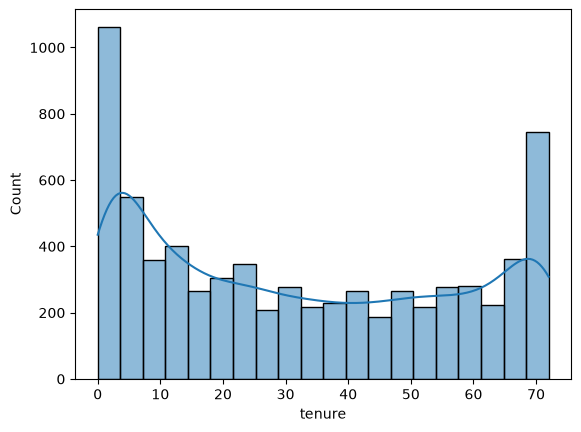

In [40]:

sns.histplot(df["tenure"], bins=20, kde=True)

In [38]:
print(f"{pd.crosstab(df['Churn_Yes'],df['PaperlessBilling_Yes'])}")
print(f"{pd.crosstab(df['Churn_Yes'],df['PaymentMethod_Bank transfer (automatic)'])}")
print(f"{pd.crosstab(df['Churn_Yes'],df['PaymentMethod_Credit card (automatic)'])}")
print(f"{pd.crosstab(df['Churn_Yes'],df['PaymentMethod_Electronic check'])}")
print(f"{pd.crosstab(df['Churn_Yes'],df['PaymentMethod_Mailed check'])}")

PaperlessBilling_Yes     0     1
Churn_Yes                       
0                     2403  2771
1                      469  1400
PaymentMethod_Bank transfer (automatic)     0     1
Churn_Yes                                          
0                                        3888  1286
1                                        1611   258
PaymentMethod_Credit card (automatic)     0     1
Churn_Yes                                        
0                                      3884  1290
1                                      1637   232
PaymentMethod_Electronic check     0     1
Churn_Yes                                 
0                               3880  1294
1                                798  1071
PaymentMethod_Mailed check     0     1
Churn_Yes                             
0                           3870  1304
1                           1561   308
